In [1]:
import numpy as np

# Integração Numérica

## Regras do Retângulo

Considerando que temos N+1 pontos, que h = $\frac{b-a}{N}$ e que $x_n= a + n.h$

$$
\begin{align}
I_{RE}(a,b,f,h)&= \sum_{n=0}^{N-1} h.f(x_n) \\
I_{RD}(a,b,f,h)&= \sum_{n=0}^{N-1} h.f(x_n + h) = \sum_{n=1}^{N} h.f(x_n) \\
I_{RC}(a,b,f,h)&= \sum_{n=0}^{N-1} h.f\left(x_n + \frac{h}{2}\right) \\
\end{align} 
$$

## Erros

Os integrais têm sempre esta forma, tal que o seu erro será função de h e do integral das suas funções derivadas. Quão maior for o n do nosso primeiro termo não nulo da expressão do erro, melhor será a nossa aproximação do integral. Desta forma iremos encontrar regras de integração ou métodos adaptativos de modo a que o primeiro maior termo possível não nulo da nossa série cada vez maior.

$$
\begin{align}
I(a, b, f) &= I_{RN}(a, b, f, h) + \sum_{n=1}^{+\infty} b_n h^n I(a, b, f^{(n)}) \\
Erro &= \sum_{n=1}^{+\infty} b_n h^n I(a, b, f^{(n)}) \tag{1} \\
\end{align}
$$
Para a regra do *Retângulo à esquerda* temos:
$$
\begin{align}
Erro_{RE}(h) &= \frac{h}{2}I(a,b,f') - \frac{h^2}{12}I(a,b,f'') + ...  \\
&= \frac{h}{2}[f(b)-f(a)] + O(h^2)\\ \label{eq:re}
\end{align}
$$
Para a regra do *Retângulo à direita* temos:
$$
\begin{align}
Erro_{RD}(h) &= -\frac{h}{2}I(a,b,f') - \frac{h^2}{12}I(a,b,f'') + ...  \\
&= \frac{h}{2}[f(a)-f(b)] + O(h^2)\\ \label{eq:rd}
\end{align}
$$
Para a regra do *Retângulo no ponto central* temos:
$$
\begin{align}
Erro_{RC}(h) &=  \frac{h^2}{24}I(a,b,f'') + ...  \\
&= \frac{h^2}{24}[f(b)-f(a)] + O(h^4)\\
\end{align}
$$

# Regra do Trapézio

$$
\begin{align}
I_T(a,b,f,h)&= \sum_{n=0}^{N-1} \frac{h}{2}[f(x_n)+f(x_n + h)]\\
&= h \left[\frac{f(x_0)}{2} + \frac{f(x_n)}{2} + \sum_{n=1}^{N-1} f(x_n)\right]\\
\end{align}
$$

Onde:

$h=(b-a)/N$ 

$x_n=a + nh$

__Também pode ser visto como:__

$$
\begin{align}
I_T(a,b,f,h)&= \sum_{n=0}^{N-1} \frac{h}{2}[f(x_n)+f(x_n + h)]\\
&= \frac{1}{2} I_{RE}(a,b,f,h) + \frac{1}{2} I_{RD}(a,b,f,h)
\end{align}
$$

__A partir desta expressão conseguimos estimar o erro à custa das expressões do erro anteriormente deduzidas. Obtemos:__

$$
\begin{align}
Erro_{T}(h) &= \frac{h^2}{12}[f'(b)-f'(a)] + O(h^4)\\
\end{align}
$$

## Estimar o Erro

À custa das equações anteriormente expostas para o erro dos diferentes métodos, podemos estimar o erro do nosso integral de uma forma simples e eficiente, a partir da comparação de dois integrais.

Veremos um exemplo da aplicação desta ideia para a regra do trapézio:

__Consideremos um integral de *f* de *a* a *b* com:__

- Um número *$N_1$* de fatias que corresponde a um passo $h_1$ = (b-a)/$N_1$
- Um número *$N_2 = 2 N_1$* de fatias que corresponde a um passo $h_2$ = (b-a)/$N_2= h_1/2 $

Tendo em conta que o erro na regra do trapézio escala com $h^2$, ao duplicarmos o número de passos estamos a diminuir o erro por um fator de 1/4.

Considerando:
- $I_1$ como o integral obtido a partir de $N_1$ passos ($I = I_1 + ch_1^2$ )
- $I_2$ como o integral obtido a partir de $N_2$ passos ($I = I_2+ ch_2^2$ )

Obtemos a seguinte igualdade:

$$
\begin{align}
I = I_1 + ch_1^2 = I_2 + ch_2^2 \Leftrightarrow & I_2 - I_1 = c(h_1^2 - h_2^2)\\
\Leftrightarrow & I_2 - I_1 = 3ch_2^2 \\
\Leftrightarrow & ch_2^2 = \frac{1}{3}(I_2 - I_1)
\end{align}
$$

Desta forma, conseguimos estimar o erro do segundo integral de uma forma simples, tendo apenas de calcular um integral extra.

__Em suma, o erro do $I_2$ considerando a regra do trapézio é:__
$$
\begin{equation}
\epsilon_2=\frac{1}{3}(I_2- I_1) \tag{2}
\end{equation}
$$

## Regra de Simpson

Desta vez, iremos considerar uma aproximação quadrática de cada subdivisão da área. 

Considerando três pontos conseguimos definir a quadrática, sendo estes $f(x_n)$, $f(x_n-h)$, $f(x_n+h)$.

Calculando o integral de um destes polinómios interpoladores temos:


$$
\begin{align}
\int_{-h}^{h}p(x) &= \left[1/3 Ax^3 + 1/2Bx^2 + Cx\right]^h_{-h}\\\\
&= 2/3 Ah^3 + 2Ch = \\\\
&= h/3 [f(h) + 4f(0 + f(-h))]
\end{align}
$$

Nota: É de notar que o integral que estamos a realizar tem $x \in [x_n-h;x_n+h]$.

Desta forma, apenas os índices ímpares serão contabilizados para o cálculo total do integral. 

__Nota importante: Os nr de intervalos N tem de ser par.__

__Obtemos a Regra de Simpson:__

$$
\begin{align}
I_S(a, b, f,h) &= \sum_{n=1,3,...}^{N-1} \frac{h}{3}[f(x_n - h) + 4f(x_n) + f(x_n + h)] \\
 &= \frac{h}{3}\left[f(a) + f(b) + 4 \sum_{n=1,3,...}^{N-1}f(a +nh) + 2 \sum_{2,4,...}^{N-2} f(a+nh)\right]\\
\end{align}
$$

__*Erro da Regra de Simpson:*__

Como vimos anteriormente, ao realizar o integral do $I_{RC}$ obtivemos uma combinação linear de erros das outras duas regras do retângulo. No Simpson algo semelhante ocorre.

$$
\begin{align}
I_S(x_n-h,x_n+h,f)&=\frac{h}{3}[f(x_n-h)+4f(x_n)+f(x_n+h)]\\
&=\frac{2}{3}I_{RC}(x_n-h,x_n+h,f)+\frac{1}{3}I_T(x_n-h,x_n+h,f)\\
{Erro}_{S}(h) &=-\frac{h^4}{90} [f'''(b) - f'''(a)] + O(h^6)
\end{align}
$$

# Estimar o Erro de Simpson

__Consideremos um integral de *f* de *a* a *b* com:__

- Um número *$N_1$* de fatias que corresponde a um passo $h_1$ = (b-a)/$N_1$
- Um número *$N_2 = 2 N_1$* de fatias que corresponde a um passo $h_2$ = (b-a)/$N_2= h_1/2 $

Tendo em conta que o erro na regra do trapézio escala com $h^4$, ao duplicarmos o número de passos estamos a diminuir o erro por um fator de 1/16.

Considerando:
- $I_1$ como o integral obtido a partir de $N_1$ passos ($I = I_1 + ch_1^2$ )
- $I_2$ como o integral obtido a partir de $N_2$ passos ($I = I_2+ ch_2^2$ )

Calculemos o erro de $I_2$:
$$
\begin{align}
I = I_1 + ch_1^4 = I_2 + ch_2^4 \Leftrightarrow & I_2 - I_1 = c(h_1^4 - h_2^4)\\
\Leftrightarrow & I_2 - I_1 = 15ch_2^4 \\
\Leftrightarrow & ch_2^4 = \frac{1}{15}(I_2 - I_1)
\end{align}
$$

__Desta forma obtemos o *Erro da Regra de Simpson*:__

$$
\begin{equation}
\epsilon_2=\frac{1}{15}(I_2-I_1) \tag{3}
\end{equation}
$$

# Métodos Adaptativos

O método adaptativo permite calcularmos um integral com uma certa precisão pré-definida a partir de uma escolha eficiente do número de intervalos $N$.

## Regra do Trapézio

A partir da ideia de duplicar o números de intervalos $N$ conseguimos generalizar a seguinte ideia:
$$
\begin{equation}
\epsilon_i=\frac{1}{3}(I_i-I_{i-1})  \tag{Trapézio}
\end{equation}
$$

Em que $N_i=2N_{i-1}$.

De modo a realizarmos o integral $I_i$ a partir do resultado do anterior conseguimos obter a seguinte expressão:

$$
\begin{equation}
I_i=\frac{1}{2}I_{i-1}+h_i \left[\sum_{k=1,3,...,N_1-1}f(a+kh_i)\right]
\end{equation}
$$

🔹 Um possível implementação básica deste método com o Trapézio:
```python

import numpy as np
def f(x):
    return x**2 + 2*x + np.exp(x)

def exact_int_f(a,b):
    b_value=b**3/3 + b**2 + np.exp(b)
    a_value=a**3/3 + a**2 + np.exp(a)
    return b_value-a_value
    
def met_trap(f,a,b,epsilon):
    int_exato=exact_int_f(a,b)
    N=2
    x=np.linspace(a,b,N+1)
    h=(b-a)/N
    I1= h/2 * (f(a)+f(b))
    print(f"Integral N={N}: {I1}")
    
    h/=2
    N*=2
    x=np.linspace(a,b,N+1)
    I2= 1/2 * I1 + h*( np.sum(f(x[1:N:2])) )
    erro=np.abs(1/3*(I2-I1))
    erro_exato=int_exato - I2
    
    print(f"Integral N={N}: {I2}   Erro 1ª Ordem: {erro:.7e}   Erro exato: {erro_exato:.7e}")
    while(erro>epsilon):
        I1=I2
        N*=2
        x=np.linspace(a,b,N+1)
        h/=2
        I2=1/2 * I1 + h*( np.sum(f(x[1:N:2])) ) ##O [1:N:] exclui termo N daí somar até N-1
        erro=np.abs(1/3*(I2-I1))
        erro_exato=int_exato - I2
        print(f"Integral N={N}: {I2}   Erro 1ª Ordem: {erro:.7e}   Erro exato: {erro_exato:.7e}")
        if(epsilon>erro):
            print(f"Resultado final:{I2}.")

met_trap(f,0,1,1e-6)

__Output:__
>>> Integral N=2: 1.679570
>>> Integral N=4: 2.346292   Erro 1ª Ordem: 2.2224038e-01   Erro exato: 7.0532357e-01
>>> Integral N=8: 2.694116   Erro 1ª Ordem: 1.1594e-01   Erro exato: 3.5750e-01
>>> Integral N=16: 2.871655   Erro 1ª Ordem: 5.9180e-02   Erro exato: 1.7996e-01
>>> Integral N=32: 2.961333   Erro 1ª Ordem: 2.9892e-02   Erro exato: 9.0282e-02
>>> Integral N=64: 3.006398   Erro 1ª Ordem: 1.5022e-02   Erro exato: 4.5217e-02
>>> Integral N=128: 3.028988   Erro 1ª Ordem: 7.5298e-03   Erro exato: 2.2627e-02
>>> Integral N=256: 3.040297   Erro 1ª Ordem: 3.7696e-03   Erro exato: 1.1318e-02
>>> Integral N=512: 3.045955   Erro 1ª Ordem: 1.8860e-03   Erro exato: 5.6604e-03
>>> Integral N=1024: 3.048785   Erro 1ª Ordem: 9.4330e-04   Erro exato: 2.8305e-03
>>> Integral N=2048: 3.050200   Erro 1ª Ordem: 4.7172e-04   Erro exato: 1.4153e-03
>>> Integral N=4096: 3.050907   Erro 1ª Ordem: 2.3588e-04   Erro exato: 7.0768e-04
>>> Integral N=8192: 3.051261   Erro 1ª Ordem: 1.1794e-04   Erro exato: 3.5384e-04
>>> Integral N=16384: 3.051438   Erro 1ª Ordem: 5.8973e-05   Erro exato: 1.7692e-04
>>> Integral N=32768: 3.051527   Erro 1ª Ordem: 2.9487e-05   Erro exato: 8.8462e-05
>>> Integral N=65536: 3.051571   Erro 1ª Ordem: 1.4744e-05   Erro exato: 4.4231e-05
>>> Integral N=131072: 3.051593   Erro 1ª Ordem: 7.3718e-06   Erro exato: 2.2115e-05
>>> Integral N=262144: 3.051604   Erro 1ª Ordem: 3.6859e-06   Erro exato: 1.1058e-05
>>> Integral N=524288: 3.051610   Erro 1ª Ordem: 1.8430e-06   Erro exato: 5.5289e-06
>>> Integral N=1048576: 3.051612   Erro 1ª Ordem: 9.2148e-07   Erro exato: 2.7644e-06
>>> Resultado final: 3.0516123973566343

# Método Adaptativo para a Regra de Simpson

Iremos fazer a mesma análise para o Simpson.

Temos que:

$$
\begin{equation}
\epsilon_i=\frac{1}{15}(I_i-I_{i-1})  \tag{Simpson}
\end{equation}
$$

A expressão de cálculo recursivo fica:

$$
\begin{align}
I_i=\frac{h_i}{3}\left[f(a) +f(b) + 2 \sum_{k=2,4,...}^{N_i-2}f(a + kh_i) + 4 \sum_{n=1,3,...}^{N_i-1} f(a + kh_i)\right]
\end{align}
$$

Definimos então:

$$
\begin{align}
S_i&=\frac{1}{3}\left[f(a)+ f(b) + 2 \sum_{k=2,4,...}^{N_i-2}f(a+kh_i)\right]\\
T_i&= \frac{2}{3}\sum_{k=1,3,...}^{N_i-1}f(a+kh_i)
\end{align}
$$

Conseguimos as seguintes relações:

$$
\begin{align}
I_i&=h_i(S_i+2T_i)\\
S_i&=S_{i-1} + T_{i-1}
\end{align}
$$

Desta forma conseguimos encontrar um método recursivo que nos permita calcular apenas pontos novos a cada sucessiva iteração.



# Método de Romberg

$$
\begin{align}
I &= I_{RN}(a, b, f, M) + \sum_{n=n_0}^{+\infty}c_nh^nI(a, b, f^{(n)}) \\
I &= I_{RN}(a, b, f, 2M) + \sum_{n=n_0}^{+\infty}c_n(h/2)^nI(a, b, f^{(n)})
\end{align}
$$

Obtemos a seguinte relação entre estes dois integrais denominada de __*Extrapolação de Richardson*__:

$$
\begin{align}
\frac{I_{RN}(a, b, f, 2M) - I_{RN}(a, b, f, M)}{2^{n_0} - 1} -
\sum_{n=n_0+1}^{+\infty} c_n \left(\frac{h}{2}\right)^n \frac{2^n - 1}{2^{n_0} - 1} I\left(a, b, f^{(n)}\right)
&= c_{n_0} \left(\frac{h}{2}\right)^{n_0} I\left(a, b, f^{(n_0)}\right)
\end{align}
$$

Então:

$$
\begin{align}
\text{Erro}_{RN, 2M} &= c_{n_0}(h/2)^{n_0}I(a, b, f^{(n_0)}) \approx \\\\
&\approx \frac{I_{RN}(a, b, f, 2M) - I_{RN}(a, b, f, M)}{2^{n_0} - 1}
\end{align}
$$

Desta forma, conseguimos fazer uma aproximação cada vez melhor do nosso integral exato, a partir dos termos de erro que vão sendo eliminados por iteração.

$$
\begin{align}
I_{\text{Melhor}} = I_{RN}(2M) + \frac{I_{RN}(2M) - I_{RN}(M)}{2^{n_0} - 1} + \tilde{c}_{n_0 + 1} h^{n_0+1} I(a, b, f^{(n_0+1)})
\end{align}
$$


Considerando os índices com o $R_{0,0}$ obtemos:

$$
\begin{align}
i &\in (0,1,...) \\  
j &\in (0,1,...) \\\\
\end{align}
$$

$$
\begin{equation}
Erro_{i,j} = \frac{I_{RN}(2M) - I_{RN}(M)}{2^{n_0} - 1} = \frac{1}{4^j - 1} \left( R_{i,i-1} - R_{i-1,i-1} \right) \tag{Trapézio}
\end{equation}
$$

$$
\begin{equation}
Erro_{i,j} = \frac{I_{RN}(2M) - I_{RN}(M)}{2^{n_0} - 1} = \frac{1}{4^{j+1} - 1} \left( R_{i,i-1} - R_{i-1,i-1} \right) \tag{Simpson}
\end{equation}
$$



Desta forma quando o nosso erro for menor que $\epsilon$ terminamos o cálculo dos integrais.


O método de Romberg usa esta técnica definindo um número de fatias $N_i=2N_{i-1}$.

__Iremos aplicar primeiro para a Regra do Trapézio:__

$$
\begin{equation}
I_i=\frac{1}{2}I_{i-1}+h_i \left[\sum_{k=1,3,...,N_1-1}f(a+kh_i)\right]
\end{equation}
$$


In [13]:
import numpy as np

def romberg_trapezio(f,a,b,max_it,epsilon):
    R=np.zeros((max_it,max_it))
    N=1
    x=np.linspace(a,b,N+1)
    h=(b-a)/N
    I1= h/2*(f(a)+f(b))
    R[0][0]=I1
    print("integral1",I1)
    for i in range(1,max_it):
        h/=2
        N*=2
        x=np.linspace(a,b,N+1)
        R[i][0]= 1/2 * R[i-1][0] + h*(np.sum(f(x[1:N:2])))
        print("aqui",R[i][0])
        for j in range(1,i+1):
            erro= 1/(4**j-1) * (R[i][j-1]-R[i-1][j-1])  ## aqui é 4^j porque começo no termo j=0, entao descarto o valor -1
            print("erro", erro)
            R[i,j]= R[i][j-1] + erro
            
            if(np.abs(erro)<epsilon):
                return print("cheguei",R[i][j])
        
    return R[max_it-1][max_it-1] 

def f_x(x):
    return x**3 + np.exp(-2*x)

a=0
b=1
max_it=10
epsilon=1e-7

import timeit

tempo_execucao = timeit.timeit(lambda: romberg_trapezio(f_x, a, b, max_it, epsilon), number=10)
print(f"Tempo médio de execução: {tempo_execucao / 10} segundos")
print(romberg_trapezio(f_x,a,b,max_it,epsilon))

integral1 1.0676676416183064
aqui 0.7802735413948744
erro -0.09579803340781068
aqui 0.706926975662703
erro -0.024448855244057117
erro -0.00013315917122785532
aqui 0.6884879973467334
erro -0.006146326105323211
erro -9.096611815710235e-06
erro -1.9661298132611814e-07
aqui 0.6838717070974469
erro -0.0015387634164288158
erro -5.818373594701498e-07
erro -3.377554537640849e-09
cheguei 0.6823323584661041
integral1 1.0676676416183064
aqui 0.7802735413948744
erro -0.09579803340781068
aqui 0.706926975662703
erro -0.024448855244057117
erro -0.00013315917122785532
aqui 0.6884879973467334
erro -0.006146326105323211
erro -9.096611815710235e-06
erro -1.9661298132611814e-07
aqui 0.6838717070974469
erro -0.0015387634164288158
erro -5.818373594701498e-07
erro -3.377554537640849e-09
cheguei 0.6823323584661041
integral1 1.0676676416183064
aqui 0.7802735413948744
erro -0.09579803340781068
aqui 0.706926975662703
erro -0.024448855244057117
erro -0.00013315917122785532
aqui 0.6884879973467334
erro -0.00614632

In [3]:
def romberg_simpson(f,a,b,max_it,epsilon):
    R=np.zeros((max_it,max_it))
    N=2
    h=(b-a)/N
    x=np.linspace(a,b,N+1)
    I1= h/3 * (f(x[0]) +f(x[-1])  + 4*f(x[1])) 
    R[0,0]=I1

    for i in range(1,max_it):
        Si_1 = 1/3*(f(x[0])+f(x[-1])+ 2* np.sum(f(x[2:N-1:2])))
        Ti_1= 2/3 * np.sum(f(x[2:N-1:2]))
        Si = Si_1 + Ti_1
        
        N*=2
        h/=2
        x=np.linspace(a,b,N+1)
        Ti= 2/3 * np.sum(f(x[1:N:2]))
        R[i,0]= h*(Si + 2*Ti)

        for j in range(1,i+1):
            erro= 1/(4**(j+1)-1) * (R[i][j-1]-R[i-1][j-1])
            
            R[i,j]= R[i][j-1] + erro
            
            if(np.abs(erro)<epsilon):
                return R[i][j] , R
       
    return R[max_it-1][max_it-1] , R

def f_x(x):
    return x**3 + np.exp(-2*x)

tempo_execucao = timeit.timeit(lambda: romberg_simpson(f_x, a, b, max_it, epsilon), number=10)
print(f"Tempo médio de execução: {tempo_execucao / 10} segundos")

Tempo médio de execução: 0.0020994000136852265 segundos


C:\Users\RodrigoGavioli\AppData\Local\Temp\ipykernel_55328\641285336.py:31: RuntimeWarning: overflow encountered in exp
  return x**3 + np.exp(-2*x)
C:\Users\RodrigoGavioli\AppData\Local\Temp\ipykernel_55328\1306388465.py:18: RuntimeWarning: invalid value encountered in scalar subtract
  erro= 1/(4**j-1) * (R[i][j-1]-R[i-1][j-1])  ## aqui é 4^j porque começo no termo j=0, entao descarto o valor -1
C:\Users\RodrigoGavioli\AppData\Local\Temp\ipykernel_55328\641285336.py:21: RuntimeWarning: invalid value encountered in scalar subtract
  erro= 1/(4**(j+1)-1) * (R[i][j-1]-R[i-1][j-1])


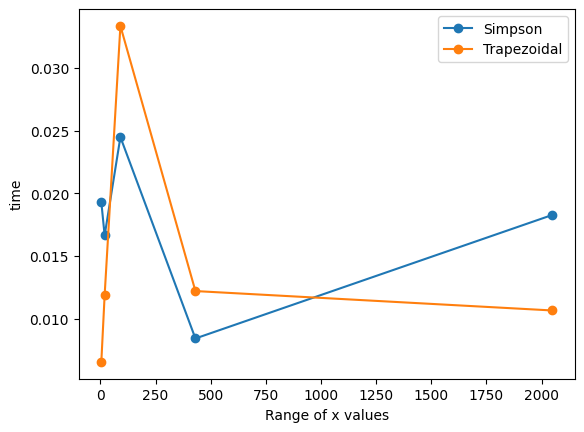

In [4]:
import matplotlib.pyplot as plt
%matplotlib inline

b_values=np.array([2**value for value in np.linspace(1,10,5)])
range_values=b_values*2

times_simpson=np.zeros(5)
times_trapezoidal=np.zeros(5)

for index,value in enumerate(b_values):
    tempo_execucao_trapezoidal = timeit.timeit(lambda: romberg_trapezio(f_x, -value, value, max_it, epsilon), number=10)
    tempo_execucao_simpson = timeit.timeit(lambda: romberg_simpson(f_x, -value, value, max_it, epsilon), number=10)
    times_simpson[index]=tempo_execucao_simpson
    times_trapezoidal[index]=tempo_execucao_trapezoidal

plt.plot(range_values,times_simpson,'o-',label='Simpson')
plt.plot(range_values,times_trapezoidal,'o-',label='Trapezoidal')
plt.xlabel('Range of x values')
plt.ylabel('time')
plt.legend()
plt.show()

__Concluimos que o trapezoidal é melhor porque requer menor computação e conseguimos obter o mesmo resultado esperado. Isto ocorre, porque o método do trapézio requer menor cálculo nas expressões recursivas para o integral na posição j=0 da matriz de Romberg. Também o nosso erro com o trapézio iguala-se ao do Simpson com apenas uma iteração extra.__

## Nota:Verificar a Diferença

In [5]:
b_values=[2**value for value in np.linspace(1,10,10)]
range_values=b_values*2
range_values

[2.0,
 4.0,
 8.0,
 16.0,
 32.0,
 64.0,
 128.0,
 256.0,
 512.0,
 1024.0,
 2.0,
 4.0,
 8.0,
 16.0,
 32.0,
 64.0,
 128.0,
 256.0,
 512.0,
 1024.0]

In [6]:
b_values=np.array([2**value for value in np.linspace(1,10,10)])
range_values=b_values*2
range_values

array([   4.,    8.,   16.,   32.,   64.,  128.,  256.,  512., 1024.,
       2048.])